<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/03_kalman_from_bayesian_glm_ready_github_dakshini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProdFusion — Kalman / Dynamic Linear Model from `bayesian_glm_ready.csv`

This Colab notebook starts from your GitHub file:

`https://github.com/dakshini01/ProdFusion/blob/main/models/bayesian_glm_ready.csv`

It then performs leakage-safe Kalman/DLM modeling:

- Load `bayesian_glm_ready.csv` from GitHub
- Automatically convert GitHub `blob` URLs to raw CSV URLs
- Support private repos using Colab Secret `GITHUB_TOKEN`
- Sort by time and split train/validation/test chronologically
- Fit a Dynamic Linear Model / Kalman filter on logit-productivity
- Tune Kalman noise parameters on the validation block
- Produce rolling one-step-ahead forecasts on the future test block
- Calculate MAE, RMSE, prediction interval coverage, AUC/AP for low-productivity risk
- Export forecast/state/metric files and a downloadable zip

Run the notebook from top to bottom in a fresh Colab runtime.

## 0. Environment repair guard

Run this first. If your Colab runtime has the NumPy/SciPy `_center` import error, this cell repairs the scientific stack and restarts the runtime.

In [1]:
# ── §0.0 Colab runtime repair guard ───────────────────────────────────────
# Run this cell first. If it repairs packages, Colab will restart automatically.
import os, sys, subprocess

PINNED_PACKAGES = [
    "numpy==2.0.2",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.9.2",
    "seaborn==0.13.2",
    "scikit-learn==1.5.2",
    "statsmodels==0.14.4",
    "tqdm",
    "requests",
]

def scientific_stack_ok():
    try:
        import numpy as np
        import pandas as pd
        import scipy
        import scipy.stats
        import scipy.linalg
        import sklearn
        import matplotlib
        return True, f"OK | numpy={np.__version__}, pandas={pd.__version__}, scipy={scipy.__version__}"
    except Exception as e:
        return False, repr(e)

ok, msg = scientific_stack_ok()
print("Scientific stack check:", msg)

if not ok:
    print("\nRepairing Colab scientific stack with pinned versions...")
    cmd = [
        sys.executable, "-m", "pip", "install",
        "-q", "--upgrade", "--force-reinstall", "--no-cache-dir",
        *PINNED_PACKAGES
    ]
    subprocess.run(cmd, check=False)
    print("\nPackages repaired. Restarting runtime now...")
    try:
        from google.colab import runtime
        runtime.unassign()
    except Exception:
        os.kill(os.getpid(), 9)
else:
    print("✓ Environment is ready.")

Scientific stack check: OK | numpy=2.0.2, pandas=2.2.2, scipy=1.16.3
✓ Environment is ready.


## 0.2 Standard imports

In [2]:
# ── §0.2 Standard imports ─────────────────────────────────────────────────
import warnings, os, io, json, base64, zipfile
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Tuple
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.linalg as linalg
from scipy.special import logit, expit

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, f1_score, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

from tqdm.auto import tqdm
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

sns.set_style("whitegrid")
np.random.seed(42)

OUT_DIR = Path("outputs/kalman")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Imports OK  | numpy", np.__version__, "| pandas", pd.__version__)
print("Output folder:", OUT_DIR.resolve())

✓ Imports OK  | numpy 2.0.2 | pandas 2.2.2
Output folder: /content/outputs/kalman


## 1. GitHub settings

This uses your settings exactly. The loader below will fix two common issues automatically:

1. `github.com/.../blob/...` is an HTML page, not a CSV. The notebook converts it to `raw.githubusercontent.com/...`.
2. `CSV_PATH_IN_REPO = 'blob/main/models/...'` is not a valid GitHub API path. The notebook normalizes it to `models/bayesian_glm_ready.csv`.

In [3]:
# ── §1.0 GitHub settings ────────────────────────────────────────────────────

# OPTION A: paste raw GitHub URL here if your repo is public.
RAW_CSV_URL = 'https://github.com/dakshini01/ProdFusion/blob/main/models/bayesian_glm_ready.csv'

# OPTION B: fill these if you do not use RAW_CSV_URL.
GITHUB_OWNER = 'dakshini01'
GITHUB_REPO = 'ProdFusion'
GITHUB_BRANCH = 'main'
CSV_PATH_IN_REPO = 'blob/main/models/bayesian_glm_ready.csv'

# For private repos: put token in Colab Secrets as GITHUB_TOKEN.
GITHUB_TOKEN = None
try:
    from google.colab import userdata
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    pass

print('GitHub settings loaded.')
print('RAW_CSV_URL set:', bool(RAW_CSV_URL.strip()))
print('Repo config:', f'{GITHUB_OWNER}/{GITHUB_REPO}@{GITHUB_BRANCH}:{CSV_PATH_IN_REPO}')
print('Token found:', bool(GITHUB_TOKEN))

GitHub settings loaded.
RAW_CSV_URL set: True
Repo config: dakshini01/ProdFusion@main:blob/main/models/bayesian_glm_ready.csv
Token found: False


## 1.1 GitHub CSV loader

In [4]:
# ── §1.1 Robust GitHub CSV loader ─────────────────────────────────────────

def github_blob_to_raw(url: str):
    # Convert github.com/owner/repo/blob/branch/path/file.csv to raw.githubusercontent.com URL.
    url = (url or "").strip()
    if not url:
        return "", None, None, None, None

    parsed = urlparse(url)
    if parsed.netloc in {"github.com", "www.github.com"} and "/blob/" in parsed.path:
        parts = parsed.path.strip("/").split("/")
        # owner/repo/blob/branch/path...
        if len(parts) >= 5 and parts[2] == "blob":
            owner = parts[0]
            repo = parts[1]
            branch = parts[3]
            path = "/".join(parts[4:])
            raw = f"https://raw.githubusercontent.com/{owner}/{repo}/{branch}/{path}"
            return raw, owner, repo, branch, path

    if parsed.netloc == "raw.githubusercontent.com":
        parts = parsed.path.strip("/").split("/")
        # owner/repo/branch/path...
        if len(parts) >= 4:
            owner = parts[0]
            repo = parts[1]
            branch = parts[2]
            path = "/".join(parts[3:])
            return url, owner, repo, branch, path

    return url, None, None, None, None


def normalize_repo_path(path: str, branch: str = "main") -> str:
    # Normalize blob/main/models/file.csv or main/models/file.csv to models/file.csv.
    path = (path or "").strip().lstrip("/")
    parts = path.split("/")

    if len(parts) >= 3 and parts[0] == "blob":
        return "/".join(parts[2:])

    if len(parts) >= 2 and parts[0] == branch:
        return "/".join(parts[1:])

    return path


def read_csv_from_text(text: str, source_name: str) -> pd.DataFrame:
    head = text[:300].lower()
    if "<!doctype html" in head or "<html" in head:
        raise ValueError(f"{source_name} returned HTML, not CSV. Use raw URL or API.")
    return pd.read_csv(io.StringIO(text))


def load_csv_from_github_settings() -> pd.DataFrame:
    errors = []

    raw_url, u_owner, u_repo, u_branch, u_path = github_blob_to_raw(RAW_CSV_URL)

    owner = u_owner or GITHUB_OWNER
    repo = u_repo or GITHUB_REPO
    branch = u_branch or GITHUB_BRANCH
    path = u_path or normalize_repo_path(CSV_PATH_IN_REPO, GITHUB_BRANCH)

    print("Resolved CSV source:")
    print("  owner :", owner)
    print("  repo  :", repo)
    print("  branch:", branch)
    print("  path  :", path)
    if raw_url:
        print("  raw_url:", raw_url)

    headers = {
        "Accept": "application/vnd.github.v3+json",
        "X-GitHub-Api-Version": "2022-11-28",
    }
    if GITHUB_TOKEN:
        headers["Authorization"] = f"Bearer {GITHUB_TOKEN}"

    # Attempt 1: raw URL
    if raw_url:
        try:
            print("\\nAttempt 1: reading via raw URL...")
            raw_headers = {}
            if GITHUB_TOKEN:
                raw_headers["Authorization"] = f"Bearer {GITHUB_TOKEN}"
            r = requests.get(raw_url, timeout=30, headers=raw_headers)
            print("  status:", r.status_code)
            r.raise_for_status()
            df = read_csv_from_text(r.text, raw_url)
            print("✓ Loaded CSV using raw URL.")
            return df
        except Exception as e:
            errors.append(f"Raw URL failed: {repr(e)}")
            print("  Raw URL failed:", repr(e))

    # Attempt 2: GitHub API contents endpoint
    try:
        print("\\nAttempt 2: reading via GitHub API contents endpoint...")
        api_path = normalize_repo_path(path, branch)
        api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{api_path}?ref={branch}"
        print("  api_url:", api_url)
        r = requests.get(api_url, headers=headers, timeout=30)
        print("  status:", r.status_code)
        r.raise_for_status()
        payload = r.json()

        if isinstance(payload, dict) and payload.get("encoding") == "base64":
            content = base64.b64decode(payload["content"]).decode("utf-8")
            df = pd.read_csv(io.StringIO(content))
            print("✓ Loaded CSV using GitHub API.")
            return df
        elif isinstance(payload, dict) and payload.get("download_url"):
            r2 = requests.get(payload["download_url"], timeout=30)
            r2.raise_for_status()
            df = read_csv_from_text(r2.text, payload["download_url"])
            print("✓ Loaded CSV using GitHub API download_url.")
            return df
        else:
            raise ValueError("GitHub API response did not contain base64 file content.")
    except Exception as e:
        errors.append(f"GitHub API failed: {repr(e)}")
        print("  GitHub API failed:", repr(e))

    # Attempt 3: manual upload fallback
    try:
        print("\\nAttempt 3: manual upload fallback...")
        from google.colab import files
        uploaded = files.upload()
        if not uploaded:
            raise ValueError("No file uploaded.")
        fname = next(iter(uploaded))
        print("✓ Uploaded:", fname)
        return pd.read_csv(io.BytesIO(uploaded[fname]))
    except Exception as e:
        errors.append(f"Manual upload failed: {repr(e)}")

    raise RuntimeError("Could not load CSV.\\n\\n" + "\\n".join(errors))


df_raw = load_csv_from_github_settings()

print("\\nShape:", df_raw.shape)
print("Columns:")
print(list(df_raw.columns))
df_raw.head()

Resolved CSV source:
  owner : dakshini01
  repo  : ProdFusion
  branch: main
  path  : models/bayesian_glm_ready.csv
  raw_url: https://raw.githubusercontent.com/dakshini01/ProdFusion/main/models/bayesian_glm_ready.csv
\nAttempt 1: reading via raw URL...
  status: 200
✓ Loaded CSV using raw URL.
\nShape: (1197, 44)
Columns:
['t', 'team', 'dept_bin', 'team_dept_idx', 'split_code', 'quarter', 'day_num', 'week_of_study', 'actual_productivity', 'productivity_beta', 'logit_productivity', 'low_productivity', 'low_productivity_abs', 'productivity_gap', 'log_incentive', 'log_wip_imputed', 'log_over_time', 'log_smv', 'log_workers', 'targeted_productivity', 'no_of_style_change', 'idle_event', 'wip_missing_flag', 'incentive_above_695', 'incentive_zero', 'style_change_flag', 'outlier_flag', 'workers_per_smv', 'cum_overtime_team', 'incentive_x_log_wip', 'log_wip_x_log_workers', 'incentive_x_workers', 'sin_dow', 'cos_dow', 'log_incentive_s', 'log_wip_imputed_s', 'log_over_time_s', 'log_smv_s', 'log

,t,team,dept_bin,team_dept_idx,split_code,quarter,day_num,week_of_study,actual_productivity,productivity_beta,...,log_incentive_s,log_wip_imputed_s,log_over_time_s,log_smv_s,log_workers_s,targeted_productivity_s,no_of_style_change_s,sin_dow_s,cos_dow_s,t_s
0,0,1,0,0,0,1,5,1,0.886500,0.886177,...,-0.985613,-0.712530,-0.866701,-1.099295,-1.329302,0.176273,-0.228886,-1.264721,0.666445,-1.651151
1,0,1,1,12,0,1,5,1,0.750428,0.750219,...,0.927705,-0.712530,0.580141,1.071580,0.916668,0.176273,-0.228886,-1.264721,0.666445,-1.651151
2,0,2,0,4,0,1,5,1,0.755167,0.754953,...,-0.985613,-0.712530,-0.866701,-1.099295,-1.329302,0.176273,-0.228886,-1.264721,0.666445,-1.651151
3,0,2,1,16,0,1,5,1,0.753098,0.752886,...,0.791130,1.293076,0.477586,0.689280,0.866049,0.176273,-0.228886,-1.264721,0.666445,-1.651151
4,0,3,1,17,0,1,5,1,0.753683,0.753472,...,0.927705,1.317723,0.580141,1.071580,0.916668,0.176273,-0.228886,-1.264721,0.666445,-1.651151


## 2. Data preparation for Kalman/DLM

In [5]:
# ── §2.0 Column detection helpers ─────────────────────────────────────────

def find_first_existing(columns, candidates):
    lower_map = {str(c).lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def is_binary_series(s):
    vals = pd.Series(s).dropna().unique()
    try:
        vals = set(pd.Series(vals).astype(float).astype(int))
        return vals.issubset({0, 1}) and len(vals) <= 2
    except Exception:
        return False

DATE_COL = find_first_existing(df_raw.columns, [
    "date", "Date", "timestamp", "Timestamp", "ds", "time", "Time"
])

TEAM_COL = find_first_existing(df_raw.columns, [
    "team", "team_no", "team_id", "line", "line_id"
])

TARGET_RAW_COL = find_first_existing(df_raw.columns, [
    "actual_productivity", "prod_clipped", "productivity", "actual", "y", "target"
])

TARGET_LOGIT_COL = find_first_existing(df_raw.columns, [
    "prod_logit", "actual_productivity_logit", "y_logit", "logit_y"
])

LOW_CLASS_COL = find_first_existing(df_raw.columns, [
    "low_flag", "is_low", "low_productivity", "class_low", "low"
])

CLASS_2_COL = find_first_existing(df_raw.columns, [
    "class_2", "class_binary", "binary_class"
])

print("Detected columns:")
print("  DATE_COL        :", DATE_COL)
print("  TEAM_COL        :", TEAM_COL)
print("  TARGET_RAW_COL  :", TARGET_RAW_COL)
print("  TARGET_LOGIT_COL:", TARGET_LOGIT_COL)
print("  LOW_CLASS_COL   :", LOW_CLASS_COL)
print("  CLASS_2_COL     :", CLASS_2_COL)

if TARGET_RAW_COL is None and TARGET_LOGIT_COL is None:
    raise ValueError(
        "No productivity target found. Expected one of: actual_productivity, prod_clipped, productivity, y, target, prod_logit."
    )

Detected columns:
  DATE_COL        : None
  TEAM_COL        : team
  TARGET_RAW_COL  : actual_productivity
  TARGET_LOGIT_COL: None
  LOW_CLASS_COL   : low_productivity
  CLASS_2_COL     : None


In [6]:
# ── §2.1 Prepare time/order, target, and feature matrix ───────────────────

LOW_PROD_TAU = 0.85
LOGIT_EPS = 1e-4
RANDOM_SEED = 42

df = df_raw.copy()

# 1) Time/order handling
if DATE_COL is not None:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    if df[DATE_COL].isna().all():
        print("WARNING: date column could not be parsed. Using row order as time.")
        DATE_COL = None

if DATE_COL is not None:
    sort_cols = [DATE_COL]
    if TEAM_COL is not None:
        sort_cols.append(TEAM_COL)
    df = df.sort_values(sort_cols).reset_index(drop=True)
    df["_time_index"] = df[DATE_COL]
else:
    df = df.reset_index(drop=True)
    df["_time_index"] = pd.RangeIndex(len(df))

# 2) Target handling
if TARGET_RAW_COL is not None:
    y_raw = pd.to_numeric(df[TARGET_RAW_COL], errors="coerce")
    y_for_logit = y_raw.clip(LOGIT_EPS, 1 - LOGIT_EPS)
    z_target = logit(y_for_logit)
    df["_y_raw"] = y_raw
    df["_z_target"] = z_target
    print(f"Using raw target column: {TARGET_RAW_COL}")
else:
    z_target = pd.to_numeric(df[TARGET_LOGIT_COL], errors="coerce")
    y_raw = pd.Series(expit(z_target), index=df.index)
    df["_y_raw"] = y_raw
    df["_z_target"] = z_target
    print(f"Using logit target column: {TARGET_LOGIT_COL}; raw target = expit(logit target)")

# Remove rows with missing target
before = len(df)
df = df.dropna(subset=["_y_raw", "_z_target"]).reset_index(drop=True)
print(f"Dropped rows with missing target: {before - len(df)}")

# 3) Low-productivity label
df["_low_actual"] = (df["_y_raw"] < LOW_PROD_TAU).astype(int)

# Optional reference label from class_2 if present
if CLASS_2_COL is not None and is_binary_series(df[CLASS_2_COL]):
    df["_low_from_class2"] = (pd.to_numeric(df[CLASS_2_COL], errors="coerce") == 0).astype(int)
    print("Reference low label created from class_2 where 0=low and 1=not-low.")

# 4) Candidate numeric features
exclude_names = {
    "_y_raw", "_z_target", "_low_actual", "_low_from_class2",
}
for c in [
    TARGET_RAW_COL, TARGET_LOGIT_COL, LOW_CLASS_COL, CLASS_2_COL,
    "actual_productivity", "prod_clipped", "prod_logit", "actual_productivity_logit",
    "class_2", "class_3", "class_binary", "class_multi", "ta_ratio",
    "low_flag", "is_low", "low_productivity", "y", "target"
]:
    if c is not None:
        exclude_names.add(c)

if DATE_COL is not None:
    exclude_names.add(DATE_COL)

df_model = df.copy()

# Add date-derived features if real date exists
if DATE_COL is not None:
    df_model["_dow"] = df_model[DATE_COL].dt.dayofweek
    df_model["_month"] = df_model[DATE_COL].dt.month
    df_model["_dayofmonth"] = df_model[DATE_COL].dt.day

# One-hot encode low-cardinality object columns except targets/date
obj_cols = [
    c for c in df_model.columns
    if df_model[c].dtype == "object" and c not in exclude_names
]
low_card_obj_cols = [c for c in obj_cols if df_model[c].nunique(dropna=True) <= 20]

if low_card_obj_cols:
    df_model = pd.get_dummies(df_model, columns=low_card_obj_cols, drop_first=True)
    print("One-hot encoded:", low_card_obj_cols)

numeric_cols = []
for c in df_model.columns:
    if c in exclude_names:
        continue
    if str(c).startswith("_") and c not in ["_dow", "_month", "_dayofmonth"]:
        continue
    if pd.api.types.is_numeric_dtype(df_model[c]):
        numeric_cols.append(c)

# Avoid ID-like columns
id_like = []
for c in numeric_cols:
    lower = str(c).lower()
    if lower in {"id", "index"} or lower.endswith("_id"):
        id_like.append(c)
numeric_cols = [c for c in numeric_cols if c not in id_like]

if len(numeric_cols) == 0:
    raise ValueError("No numeric features available for DLM after exclusions.")

print("\\nSelected DLM feature columns:")
for c in numeric_cols:
    print(" -", c)

print("\\nPrepared shape:", df_model.shape)
print("Target raw range:", float(df_model["_y_raw"].min()), "to", float(df_model["_y_raw"].max()))
print("Low label rate using y < 0.85:", float(df_model["_low_actual"].mean()))
df_model.head()

Using raw target column: actual_productivity
Dropped rows with missing target: 0
\nSelected DLM feature columns:
 - t
 - team
 - dept_bin
 - team_dept_idx
 - split_code
 - quarter
 - day_num
 - week_of_study
 - productivity_beta
 - logit_productivity
 - low_productivity_abs
 - productivity_gap
 - log_incentive
 - log_wip_imputed
 - log_over_time
 - log_smv
 - log_workers
 - targeted_productivity
 - no_of_style_change
 - idle_event
 - wip_missing_flag
 - incentive_above_695
 - incentive_zero
 - style_change_flag
 - outlier_flag
 - workers_per_smv
 - cum_overtime_team
 - incentive_x_log_wip
 - log_wip_x_log_workers
 - incentive_x_workers
 - sin_dow
 - cos_dow
 - log_incentive_s
 - log_wip_imputed_s
 - log_over_time_s
 - log_smv_s
 - log_workers_s
 - targeted_productivity_s
 - no_of_style_change_s
 - sin_dow_s
 - cos_dow_s
 - t_s
\nPrepared shape: (1197, 48)
Target raw range: 0.233705476 to 1.1204375
Low label rate using y < 0.85: 0.7326649958228906


,t,team,dept_bin,team_dept_idx,split_code,quarter,day_num,week_of_study,actual_productivity,productivity_beta,...,log_workers_s,targeted_productivity_s,no_of_style_change_s,sin_dow_s,cos_dow_s,t_s,_time_index,_y_raw,_z_target,_low_actual
0,0,1,0,0,0,1,5,1,0.886500,0.886177,...,-1.329302,0.176273,-0.228886,-1.264721,0.666445,-1.651151,0,0.886500,2.055478,0
1,0,1,1,12,0,1,5,1,0.750428,0.750219,...,0.916668,0.176273,-0.228886,-1.264721,0.666445,-1.651151,1,0.750428,1.100895,1
2,0,2,0,4,0,1,5,1,0.755167,0.754953,...,-1.329302,0.176273,-0.228886,-1.264721,0.666445,-1.651151,2,0.755167,1.126361,1
3,0,2,1,16,0,1,5,1,0.753098,0.752886,...,0.866049,0.176273,-0.228886,-1.264721,0.666445,-1.651151,3,0.753098,1.115201,1
4,0,3,1,17,0,1,5,1,0.753683,0.753472,...,0.916668,0.176273,-0.228886,-1.264721,0.666445,-1.651151,4,0.753683,1.118355,1


## 3. Leakage-safe temporal split

Kalman modeling must be time-aware. This notebook does not use random split. It sorts data by date if available, otherwise by row order.

In [7]:
# ── §3.0 Time-safe split ─────────────────────────────────────────────────

def temporal_split_indices(df_in, date_col=None, train_frac=0.60, val_frac=0.20):
    n = len(df_in)

    if date_col is not None:
        unique_dates = pd.Series(df_in[date_col].dropna().sort_values().unique())
        if len(unique_dates) >= 5:
            n_train_dates = max(1, int(len(unique_dates) * train_frac))
            n_val_dates = max(1, int(len(unique_dates) * val_frac))

            train_end_date = unique_dates.iloc[n_train_dates - 1]
            val_end_date = unique_dates.iloc[min(n_train_dates + n_val_dates - 1, len(unique_dates) - 1)]

            tr_idx = df_in.index[df_in[date_col] <= train_end_date].to_numpy()
            val_idx = df_in.index[(df_in[date_col] > train_end_date) & (df_in[date_col] <= val_end_date)].to_numpy()
            te_idx = df_in.index[df_in[date_col] > val_end_date].to_numpy()

            if len(te_idx) > 0 and len(val_idx) > 0:
                return tr_idx, val_idx, te_idx, "date-block"

    n_train = max(1, int(n * train_frac))
    n_val = max(1, int(n * val_frac))
    tr_idx = np.arange(0, n_train)
    val_idx = np.arange(n_train, min(n_train + n_val, n))
    te_idx = np.arange(min(n_train + n_val, n), n)
    return tr_idx, val_idx, te_idx, "row-order"


tr_idx, val_idx, te_idx, split_method = temporal_split_indices(df_model, DATE_COL)

if len(te_idx) == 0:
    raise ValueError("Test split is empty. Need more rows/dates for temporal split.")

df_tr = df_model.iloc[tr_idx].copy().reset_index(drop=True)
df_val = df_model.iloc[val_idx].copy().reset_index(drop=True)
df_te = df_model.iloc[te_idx].copy().reset_index(drop=True)

print("Split method:", split_method)
print("Train rows:", len(df_tr))
print("Val rows  :", len(df_val))
print("Test rows :", len(df_te))

if DATE_COL is not None:
    for name, dfx in [("TRAIN", df_tr), ("VAL", df_val), ("TEST", df_te)]:
        print(f"{name:5s}: {dfx[DATE_COL].min()} -> {dfx[DATE_COL].max()}")

# Median imputation fit only on train
train_medians = df_tr[numeric_cols].median(numeric_only=True)
X_tr_raw = df_tr[numeric_cols].fillna(train_medians).replace([np.inf, -np.inf], np.nan).fillna(train_medians)
X_val_raw = df_val[numeric_cols].fillna(train_medians).replace([np.inf, -np.inf], np.nan).fillna(train_medians)
X_te_raw = df_te[numeric_cols].fillna(train_medians).replace([np.inf, -np.inf], np.nan).fillna(train_medians)

scaler = StandardScaler().fit(X_tr_raw)
X_tr = scaler.transform(X_tr_raw)
X_val = scaler.transform(X_val_raw)
X_te = scaler.transform(X_te_raw)

# Add intercept
F_tr = np.column_stack([np.ones(len(X_tr)), X_tr])
F_val = np.column_stack([np.ones(len(X_val)), X_val])
F_te = np.column_stack([np.ones(len(X_te)), X_te])

Z_tr = df_tr["_z_target"].to_numpy()
Z_val = df_val["_z_target"].to_numpy()
Z_te = df_te["_z_target"].to_numpy()

Y_tr = df_tr["_y_raw"].to_numpy()
Y_val = df_val["_y_raw"].to_numpy()
Y_te = df_te["_y_raw"].to_numpy()

LOW_te = df_te["_low_actual"].to_numpy()

feature_names = ["intercept"] + numeric_cols
p = F_tr.shape[1]

print("\\nDLM matrix shapes:")
print("F_tr:", F_tr.shape, "| F_val:", F_val.shape, "| F_te:", F_te.shape)
print("State dimension p:", p)

Split method: row-order
Train rows: 718
Val rows  : 239
Test rows : 240
\nDLM matrix shapes:
F_tr: (718, 43) | F_val: (239, 43) | F_te: (240, 43)
State dimension p: 43


## 4. Dynamic Linear Model / Kalman Filter implementation

In [8]:
# ── §4.0 Dynamic Linear Model class ───────────────────────────────────────

class TVRegDLM:
    # Time-varying regression DLM/Kalman filter.
    # Observation: z_t = F_t @ theta_t + v_t, v_t ~ N(0, R)
    # State: theta_t = theta_{t-1} + w_t, w_t ~ N(0, Q)
    # This is a random-walk coefficient model.

    def __init__(self, p, R=1.0, Q_diag=None, m0=None, C0=None):
        self.p = int(p)
        self.R = float(R)
        self.Q = np.diag(Q_diag if Q_diag is not None else np.full(p, 1e-4)).astype(float)
        self.m0 = np.asarray(m0 if m0 is not None else np.zeros(p), dtype=float)
        self.C0 = np.asarray(C0 if C0 is not None else np.eye(p) * 10.0, dtype=float)

    def filter(self, Z, F):
        Z = np.asarray(Z, dtype=float)
        F = np.asarray(F, dtype=float)

        T = len(Z)
        ms = np.zeros((T, self.p))
        Cs = np.zeros((T, self.p, self.p))
        pred_state_mean = np.zeros((T, self.p))
        pred_state_cov = np.zeros((T, self.p, self.p))
        pred_obs_mean = np.zeros(T)
        pred_obs_var = np.zeros(T)
        innovations = np.zeros(T)

        m = self.m0.copy()
        C = self.C0.copy()

        for t in range(T):
            ft = F[t]

            # Predict
            a = m
            R_t = C + self.Q

            f_hat = float(ft @ a)
            Q_obs = float(ft @ R_t @ ft + self.R)
            Q_obs = max(Q_obs, 1e-9)

            # Update
            e = float(Z[t] - f_hat)
            K = R_t @ ft / Q_obs
            m = a + K * e
            C = R_t - np.outer(K, ft) @ R_t
            C = (C + C.T) / 2

            ms[t] = m
            Cs[t] = C
            pred_state_mean[t] = a
            pred_state_cov[t] = R_t
            pred_obs_mean[t] = f_hat
            pred_obs_var[t] = Q_obs
            innovations[t] = e

        self.ms_ = ms
        self.Cs_ = Cs
        self.pred_state_mean_ = pred_state_mean
        self.pred_state_cov_ = pred_state_cov
        self.pred_obs_mean_ = pred_obs_mean
        self.pred_obs_var_ = pred_obs_var
        self.innovations_ = innovations
        return ms, Cs

    def log_likelihood_after_warm_start(self, Z, F):
        self.filter(Z, F)
        v = np.maximum(self.pred_obs_var_, 1e-9)
        e = self.innovations_
        return float(-0.5 * np.sum(np.log(2 * np.pi * v) + (e ** 2) / v))

    def smooth(self):
        if not hasattr(self, "ms_"):
            raise RuntimeError("Call filter() before smooth().")

        T = len(self.ms_)
        ms_s = self.ms_.copy()
        Cs_s = self.Cs_.copy()

        for t in range(T - 2, -1, -1):
            R_next = self.pred_state_cov_[t + 1]
            A = self.Cs_[t] @ np.linalg.pinv(R_next)
            ms_s[t] = self.ms_[t] + A @ (ms_s[t + 1] - self.pred_state_mean_[t + 1])
            Cs_s[t] = self.Cs_[t] + A @ (Cs_s[t + 1] - R_next) @ A.T
            Cs_s[t] = (Cs_s[t] + Cs_s[t].T) / 2

        self.ms_smooth_ = ms_s
        self.Cs_smooth_ = Cs_s
        return ms_s, Cs_s


def rolling_forecast_update(dlm, F_test, Z_test, n_mc=3000, low_tau=0.85):
    # Roll through test observations:
    # forecast before seeing y_t, then update using y_t.
    n = len(Z_test)
    pred_z = np.zeros(n)
    pred_var = np.zeros(n)

    m = dlm.m0.copy()
    C = dlm.C0.copy()

    for t in range(n):
        ft = F_test[t]

        a = m
        R_t = C + dlm.Q

        f_hat = float(ft @ a)
        Q_obs = float(ft @ R_t @ ft + dlm.R)
        Q_obs = max(Q_obs, 1e-9)

        pred_z[t] = f_hat
        pred_var[t] = Q_obs

        # Update after observing Z_test[t]
        e = float(Z_test[t] - f_hat)
        K = R_t @ ft / Q_obs
        m = a + K * e
        C = R_t - np.outer(K, ft) @ R_t
        C = (C + C.T) / 2

    pred_std = np.sqrt(np.maximum(pred_var, 1e-9))
    mc_z = np.random.normal(pred_z[:, None], pred_std[:, None], size=(n, n_mc))
    mc_y = expit(mc_z)

    return {
        "pred_z": pred_z,
        "pred_std": pred_std,
        "pred_mean": expit(pred_z),
        "lower80": np.percentile(mc_y, 10, axis=1),
        "upper80": np.percentile(mc_y, 90, axis=1),
        "lower95": np.percentile(mc_y, 2.5, axis=1),
        "upper95": np.percentile(mc_y, 97.5, axis=1),
        "prob_low": (mc_y < low_tau).mean(axis=1),
    }

print("✓ TVRegDLM ready.")

✓ TVRegDLM ready.


## 5. Tune Kalman noise parameters on validation data

R grid:   0%|          | 0/10 [00:00<?, ?it/s]

Best validation setting:
{'ll': 227.124187918267, 'R': np.float64(0.01), 'Q': np.float64(1e-06)}


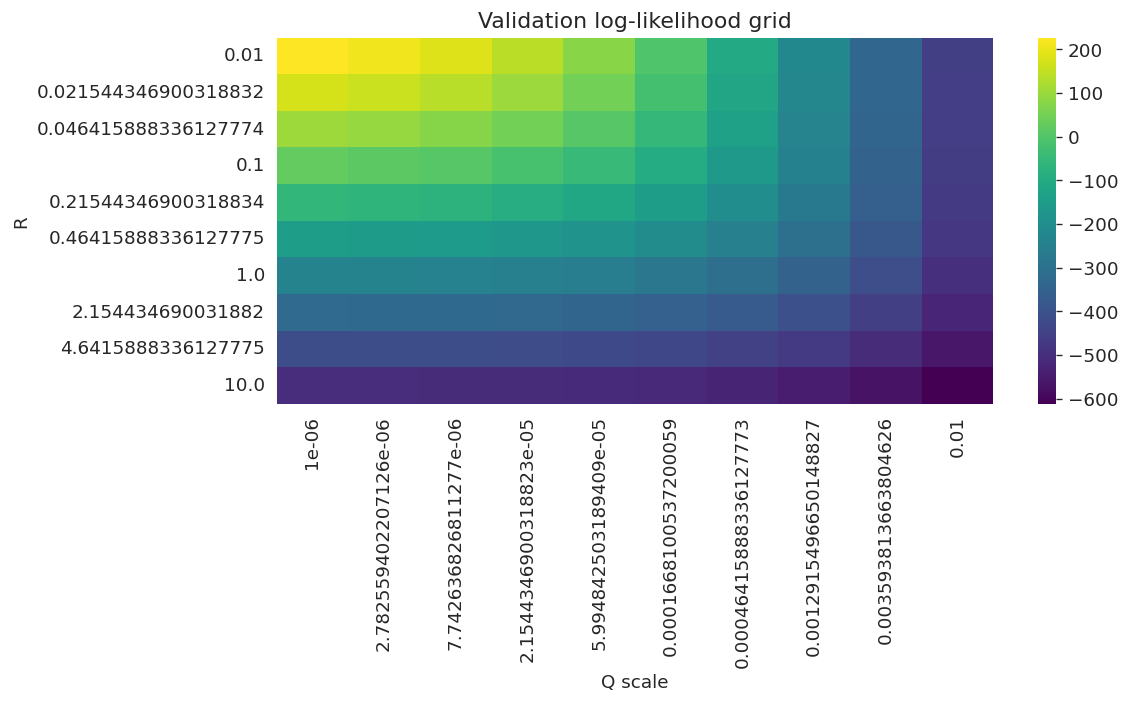

In [9]:
# ── §5.0 Validation tuning for R and Q ────────────────────────────────────

# Use compact grids so Colab runs fast.
R_GRID = np.logspace(-2, 1, 10)
Q_GRID = np.logspace(-6, -2, 10)

best = {"ll": -np.inf, "R": None, "Q": None}
ll_table = []

for R in tqdm(R_GRID, desc="R grid"):
    for Qsc in Q_GRID:
        # Fit/train first
        dlm_train = TVRegDLM(
            p=p,
            R=R,
            Q_diag=np.full(p, Qsc),
            m0=np.zeros(p),
            C0=np.eye(p) * 10.0
        )
        dlm_train.filter(Z_tr, F_tr)

        # Warm-start validation from end of train
        dlm_val = TVRegDLM(
            p=p,
            R=R,
            Q_diag=np.full(p, Qsc),
            m0=dlm_train.ms_[-1],
            C0=dlm_train.Cs_[-1]
        )
        ll = dlm_val.log_likelihood_after_warm_start(Z_val, F_val)

        ll_table.append({"R": R, "Q_scale": Qsc, "val_loglik": ll})
        if ll > best["ll"]:
            best = {"ll": ll, "R": R, "Q": Qsc}

tuning_df = pd.DataFrame(ll_table)
tuning_df.to_csv(OUT_DIR / "dlm_tuning_grid.csv", index=False)

print("Best validation setting:")
print(best)

pivot = tuning_df.pivot(index="R", columns="Q_scale", values="val_loglik")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Validation log-likelihood grid")
plt.xlabel("Q scale")
plt.ylabel("R")
plt.tight_layout()
plt.savefig(OUT_DIR / "dlm_tuning_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Fit final DLM on train + validation and forecast test

In [10]:
# ── §6.0 Final fit on train+val ───────────────────────────────────────────

F_trainval = np.vstack([F_tr, F_val])
Z_trainval = np.concatenate([Z_tr, Z_val])
Y_trainval = np.concatenate([Y_tr, Y_val])
df_trainval = pd.concat([df_tr, df_val], ignore_index=True)

dlm_final = TVRegDLM(
    p=p,
    R=best["R"],
    Q_diag=np.full(p, best["Q"]),
    m0=np.zeros(p),
    C0=np.eye(p) * 10.0
)

ms, Cs = dlm_final.filter(Z_trainval, F_trainval)
ms_s, Cs_s = dlm_final.smooth()

fitted_y = expit(dlm_final.pred_obs_mean_)
mae_trainval = mean_absolute_error(Y_trainval, fitted_y)
rmse_trainval = np.sqrt(mean_squared_error(Y_trainval, fitted_y))

print("Final DLM fit complete.")
print("Train+val MAE :", round(mae_trainval, 4))
print("Train+val RMSE:", round(rmse_trainval, 4))

# Warm-start test rolling forecast from final train+val state
dlm_test = TVRegDLM(
    p=p,
    R=best["R"],
    Q_diag=np.full(p, best["Q"]),
    m0=dlm_final.ms_[-1],
    C0=dlm_final.Cs_[-1]
)

forecast = rolling_forecast_update(
    dlm_test, F_te, Z_te, n_mc=3000, low_tau=LOW_PROD_TAU
)

pred_mean = forecast["pred_mean"]
prob_low = forecast["prob_low"]

mae_test = mean_absolute_error(Y_te, pred_mean)
rmse_test = np.sqrt(mean_squared_error(Y_te, pred_mean))
r2_test = r2_score(Y_te, pred_mean) if len(Y_te) > 1 else np.nan

cov80 = np.mean((Y_te >= forecast["lower80"]) & (Y_te <= forecast["upper80"]))
cov95 = np.mean((Y_te >= forecast["lower95"]) & (Y_te <= forecast["upper95"]))

print("\\nRolling future test metrics:")
print("Test MAE        :", round(mae_test, 4))
print("Test RMSE       :", round(rmse_test, 4))
print("Test R2         :", round(float(r2_test), 4) if not np.isnan(r2_test) else "NA")
print("80% PI coverage :", round(float(cov80), 4))
print("95% PI coverage :", round(float(cov95), 4))

Final DLM fit complete.
Train+val MAE : 0.0075
Train+val RMSE: 0.0296
\nRolling future test metrics:
Test MAE        : 0.0048
Test RMSE       : 0.0067
Test R2         : 0.9982
80% PI coverage : 0.9917
95% PI coverage : 0.9917


## 7. Forecast plots and low-productivity risk

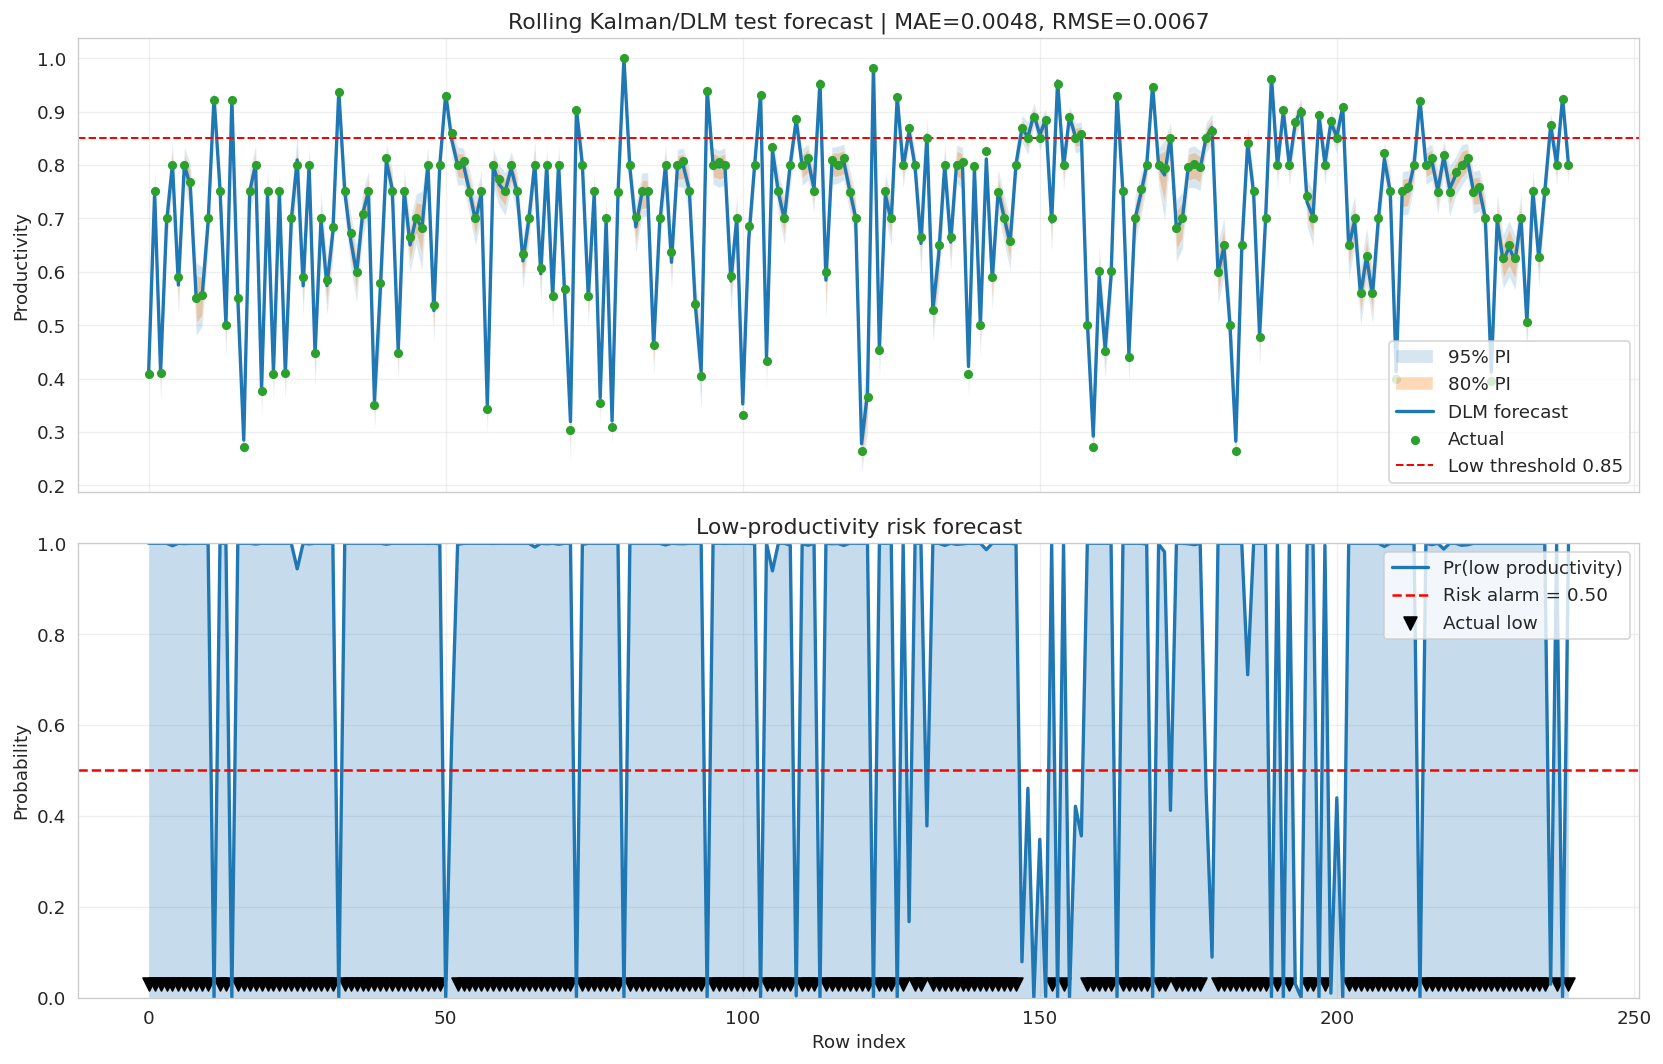

In [11]:
# ── §7.0 Plot rolling forecast ────────────────────────────────────────────

if DATE_COL is not None:
    x_test = df_te[DATE_COL]
    x_trainval = df_trainval[DATE_COL]
    x_label = "Date"
else:
    x_test = np.arange(len(df_te))
    x_trainval = np.arange(len(df_trainval))
    x_label = "Row index"

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.fill_between(x_test, forecast["lower95"], forecast["upper95"], alpha=0.18, label="95% PI")
ax.fill_between(x_test, forecast["lower80"], forecast["upper80"], alpha=0.30, label="80% PI")
ax.plot(x_test, pred_mean, linewidth=2, label="DLM forecast")
ax.scatter(x_test, Y_te, s=20, label="Actual", zorder=5)
ax.axhline(LOW_PROD_TAU, color="red", linestyle="--", linewidth=1.2, label=f"Low threshold {LOW_PROD_TAU}")
ax.set_ylabel("Productivity")
ax.set_title(f"Rolling Kalman/DLM test forecast | MAE={mae_test:.4f}, RMSE={rmse_test:.4f}")
ax.legend(loc="best")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x_test, prob_low, linewidth=2, label="Pr(low productivity)")
ax.fill_between(x_test, 0, prob_low, alpha=0.25)
ax.axhline(0.50, color="red", linestyle="--", label="Risk alarm = 0.50")
actual_low = LOW_te.astype(bool)
ax.scatter(np.array(x_test)[actual_low], np.ones(actual_low.sum()) * 0.03,
           marker="v", s=60, color="black", label="Actual low")
ax.set_ylim(0, 1)
ax.set_ylabel("Probability")
ax.set_xlabel(x_label)
ax.set_title("Low-productivity risk forecast")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "dlm_rolling_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── §7.1 Classification-style low-risk metrics ────────────────────────────

# y_low = 1 means low productivity
y_low = LOW_te.astype(int)
score_low = prob_low

risk_threshold = 0.50
pred_low = (score_low >= risk_threshold).astype(int)

acc_low = accuracy_score(y_low, pred_low)
f1_low = f1_score(y_low, pred_low, zero_division=0)

metrics = {
    "best_R": float(best["R"]),
    "best_Q_scale": float(best["Q"]),
    "trainval_mae": float(mae_trainval),
    "trainval_rmse": float(rmse_trainval),
    "test_mae": float(mae_test),
    "test_rmse": float(rmse_test),
    "test_r2": None if np.isnan(r2_test) else float(r2_test),
    "coverage_80": float(cov80),
    "coverage_95": float(cov95),
    "low_threshold_y": float(LOW_PROD_TAU),
    "risk_alarm_threshold": float(risk_threshold),
    "low_accuracy": float(acc_low),
    "low_f1": float(f1_low),
}

if len(np.unique(y_low)) == 2:
    auc_low = roc_auc_score(y_low, score_low)
    ap_low = average_precision_score(y_low, score_low)
    metrics["low_auc"] = float(auc_low)
    metrics["low_average_precision"] = float(ap_low)
    print("Low-productivity AUC:", round(auc_low, 4))
    print("Low-productivity AP :", round(ap_low, 4))
else:
    print("AUC/AP skipped because the test block has only one low/not-low class.")

print("\\nClassification report at risk threshold 0.50:")
print(classification_report(y_low, pred_low, target_names=["Not low", "Low"], zero_division=0))

with open(OUT_DIR / "dlm_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

metrics

Low-productivity AUC: 1.0
Low-productivity AP : 1.0
\nClassification report at risk threshold 0.50:
              precision    recall  f1-score   support

     Not low       1.00      0.97      0.99        40
         Low       1.00      1.00      1.00       200

    accuracy                           1.00       240
   macro avg       1.00      0.99      0.99       240
weighted avg       1.00      1.00      1.00       240



{'best_R': 0.01,
 'best_Q_scale': 1e-06,
 'trainval_mae': 0.007546503247716346,
 'trainval_rmse': 0.029645304570380192,
 'test_mae': 0.00480612720992274,
 'test_rmse': 0.006678538860195464,
 'test_r2': 0.9982143529207901,
 'coverage_80': 0.9916666666666667,
 'coverage_95': 0.9916666666666667,
 'low_threshold_y': 0.85,
 'risk_alarm_threshold': 0.5,
 'low_accuracy': 0.9958333333333333,
 'low_f1': 0.9975062344139651,
 'low_auc': 1.0,
 'low_average_precision': 1.0}

## 8. Time-varying coefficient drift

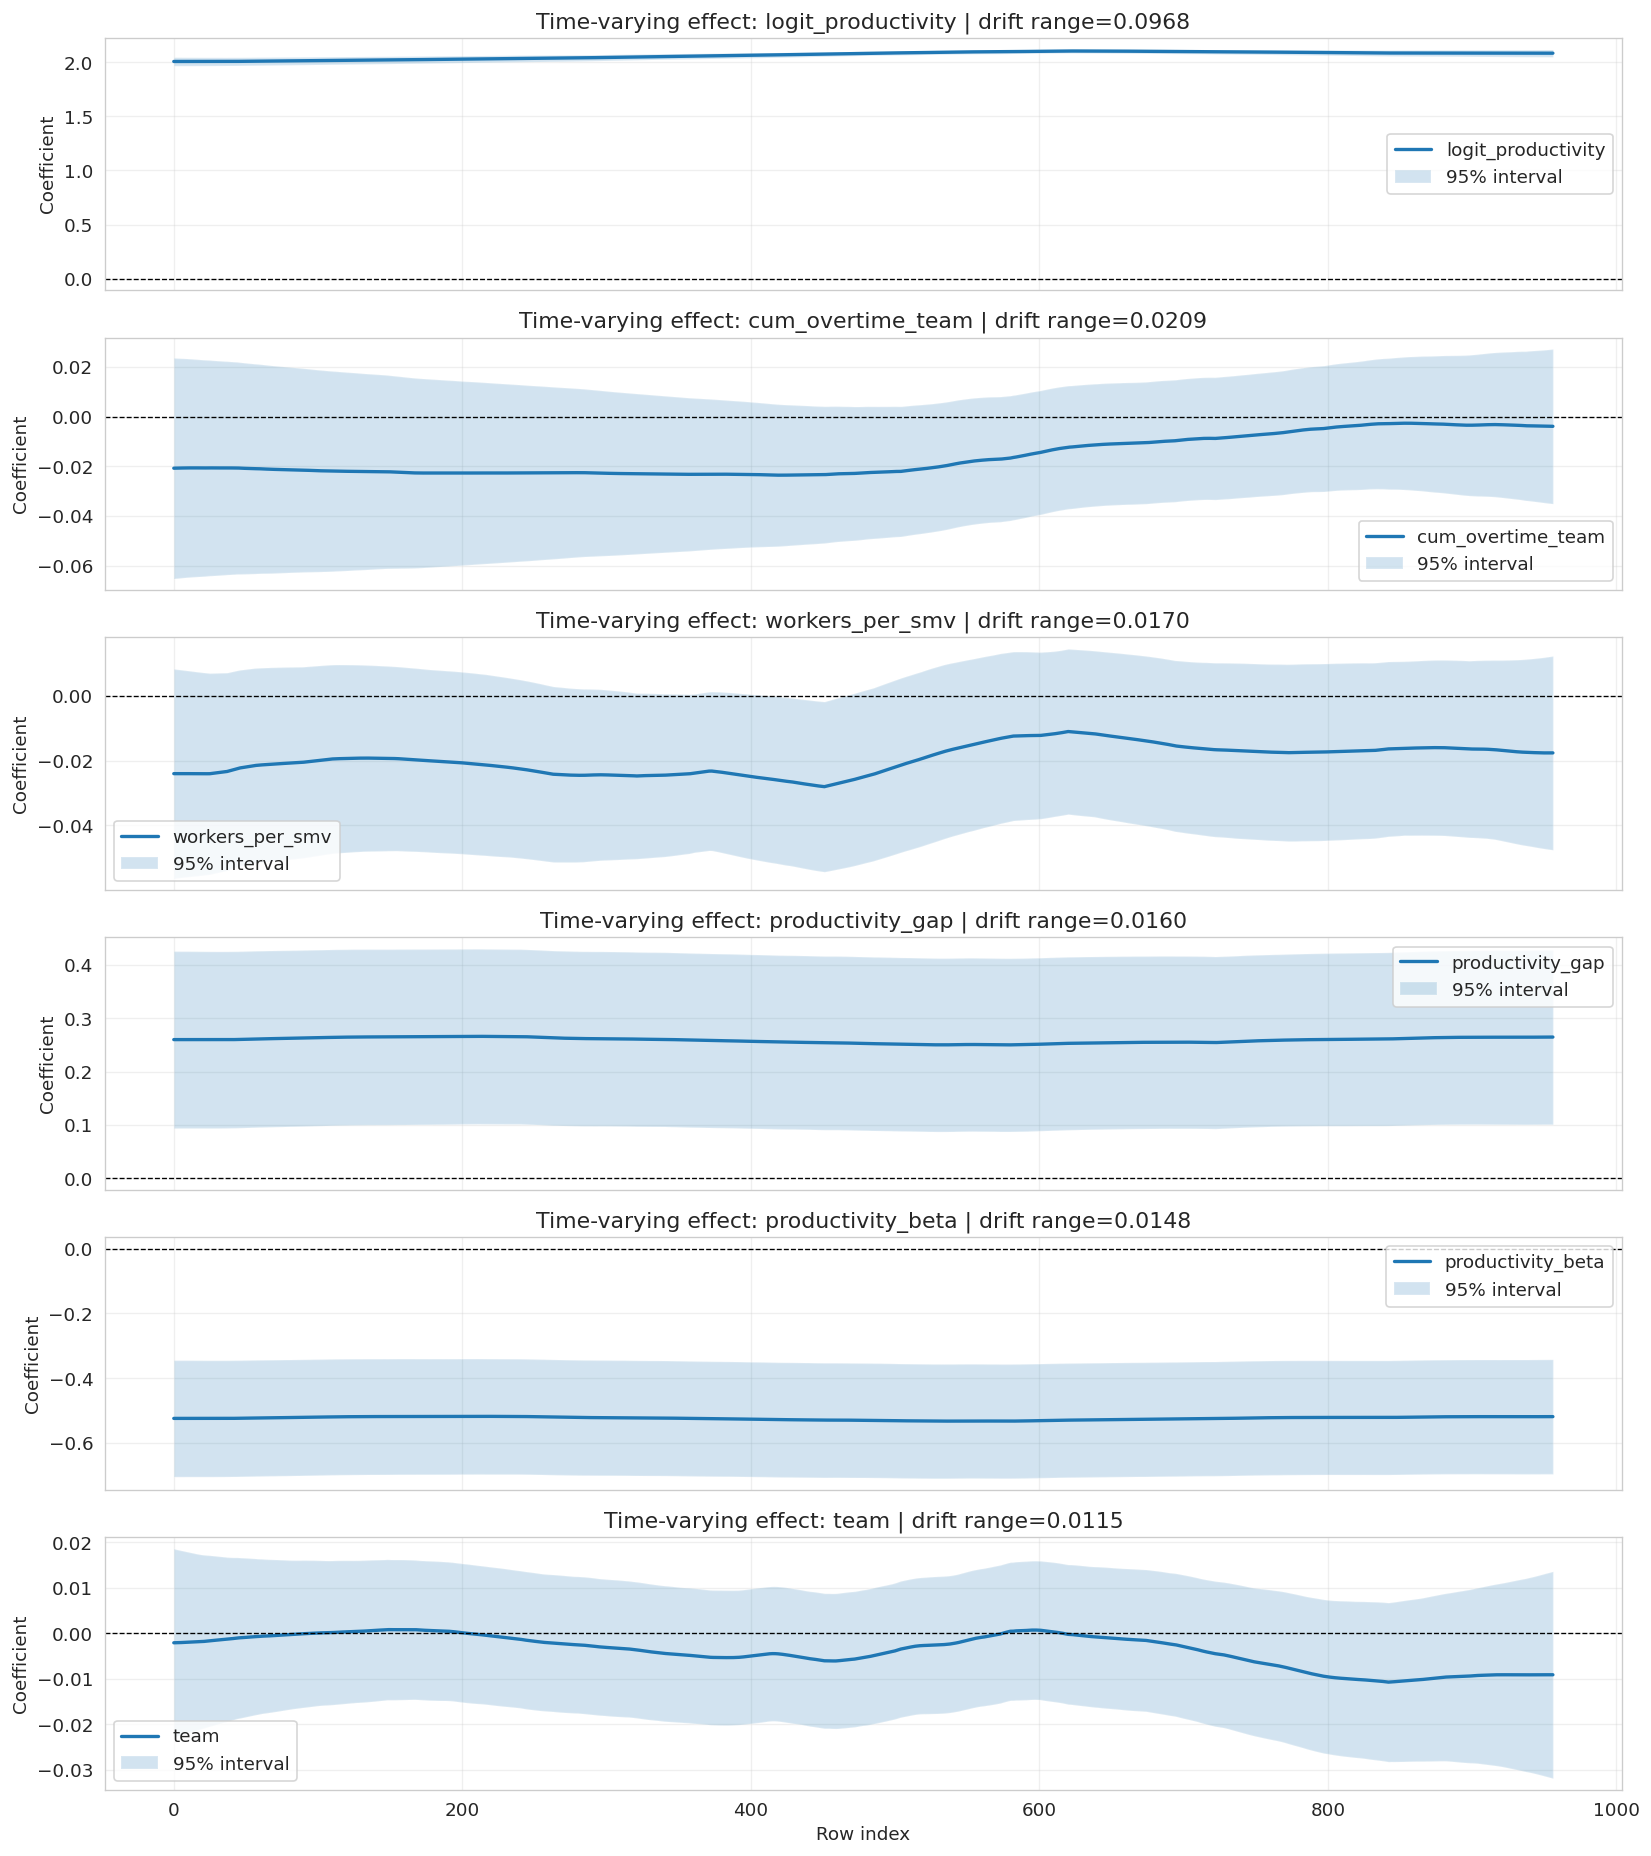

Top drift features:
logit_productivity             range = 0.0968
cum_overtime_team              range = 0.0209
workers_per_smv                range = 0.0170
productivity_gap               range = 0.0160
productivity_beta              range = 0.0148
team                           range = 0.0115


In [13]:
# ── §8.0 State/coefficient export and drift plot ──────────────────────────

state_df = pd.DataFrame(ms_s, columns=[f"state_{name}" for name in feature_names])
if DATE_COL is not None:
    state_df[DATE_COL] = df_trainval[DATE_COL].values
state_df.to_csv(OUT_DIR / "dlm_filtered_smoothed_states.csv", index=False)

# Pick top coefficients by drift range, excluding intercept if possible
ranges = np.ptp(ms_s, axis=0)
order = np.argsort(ranges)[::-1]
show_idx = [j for j in order if feature_names[j] != "intercept"][:6]
if not show_idx:
    show_idx = order[:6]

fig, axes = plt.subplots(len(show_idx), 1, figsize=(14, 2.6 * len(show_idx)), sharex=True)
if len(show_idx) == 1:
    axes = [axes]

for ax, j in zip(axes, show_idx):
    coeff = ms_s[:, j]
    std = np.sqrt(np.maximum(Cs_s[:, j, j], 1e-12))
    x = df_trainval[DATE_COL] if DATE_COL is not None else np.arange(len(df_trainval))

    ax.plot(x, coeff, linewidth=2, label=feature_names[j])
    ax.fill_between(x, coeff - 1.96 * std, coeff + 1.96 * std, alpha=0.20, label="95% interval")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.set_ylabel("Coefficient")
    ax.set_title(f"Time-varying effect: {feature_names[j]} | drift range={ranges[j]:.4f}")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)

plt.xlabel("Date" if DATE_COL is not None else "Row index")
plt.tight_layout()
plt.savefig(OUT_DIR / "dlm_coefficient_drift.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top drift features:")
for j in show_idx:
    print(f"{feature_names[j]:30s} range = {ranges[j]:.4f}")

## 9. What-if curves for available operational levers

In [14]:
# ── §9.0 What-if analysis ─────────────────────────────────────────────────

available_levers = [c for c in ["incentive", "wip", "no_of_workers", "over_time"] if c in numeric_cols]

if not available_levers:
    print("No standard operational levers found among numeric features.")
    print("Expected one or more of: incentive, wip, no_of_workers, over_time")
else:
    print("Available levers:", available_levers)

    baseline = X_te_raw.median().to_dict()
    terminal_m = dlm_final.ms_[-1]
    terminal_C = dlm_final.Cs_[-1]

    def predict_for_raw_features(raw_feature_dict, n_mc=2000):
        x_df = pd.DataFrame([raw_feature_dict])[numeric_cols]
        x_df = x_df.fillna(train_medians)
        x_scaled = scaler.transform(x_df)
        ft = np.concatenate([[1.0], x_scaled[0]])

        a = terminal_m
        R_t = terminal_C + dlm_final.Q
        z_hat = float(ft @ a)
        var_hat = float(ft @ R_t @ ft + dlm_final.R)
        var_hat = max(var_hat, 1e-9)

        samples_y = expit(np.random.normal(z_hat, np.sqrt(var_hat), n_mc))
        return {
            "mean": float(expit(z_hat)),
            "lower80": float(np.percentile(samples_y, 10)),
            "upper80": float(np.percentile(samples_y, 90)),
            "prob_low": float((samples_y < LOW_PROD_TAU).mean()),
        }

    whatif_rows = []

    fig, axes = plt.subplots(len(available_levers), 2, figsize=(14, 4 * len(available_levers)))
    if len(available_levers) == 1:
        axes = np.array([axes])

    for row_i, lever in enumerate(available_levers):
        base_val = float(baseline[lever])
        col = X_te_raw[lever].dropna()
        spread = float(col.std()) if float(col.std()) > 0 else max(abs(base_val) * 0.25, 1.0)

        deltas = np.linspace(-2 * spread, 2 * spread, 41)
        means, lows, lo80, hi80 = [], [], [], []

        for d in deltas:
            raw = baseline.copy()
            raw[lever] = base_val + d
            if lever in ["incentive", "wip", "no_of_workers", "over_time"]:
                raw[lever] = max(0, raw[lever])
            out = predict_for_raw_features(raw)
            means.append(out["mean"])
            lo80.append(out["lower80"])
            hi80.append(out["upper80"])
            lows.append(out["prob_low"])
            whatif_rows.append({
                "lever": lever,
                "baseline_value": base_val,
                "delta": float(d),
                "new_value": float(raw[lever]),
                "expected_productivity": out["mean"],
                "lower80": out["lower80"],
                "upper80": out["upper80"],
                "prob_low": out["prob_low"],
            })

        ax1 = axes[row_i, 0]
        ax1.plot(base_val + deltas, means, linewidth=2)
        ax1.fill_between(base_val + deltas, lo80, hi80, alpha=0.25)
        ax1.axvline(base_val, color="black", linestyle="--", label="Baseline")
        ax1.axhline(LOW_PROD_TAU, color="red", linestyle="--", label="Low threshold")
        ax1.set_title(f"What-if expected productivity: {lever}")
        ax1.set_xlabel(lever)
        ax1.set_ylabel("Expected productivity")
        ax1.legend()
        ax1.grid(alpha=0.3)

        ax2 = axes[row_i, 1]
        ax2.plot(base_val + deltas, lows, linewidth=2, color="red")
        ax2.axvline(base_val, color="black", linestyle="--", label="Baseline")
        ax2.axhline(0.50, color="gray", linestyle="--", label="Risk 0.50")
        ax2.set_ylim(0, 1)
        ax2.set_title(f"What-if low-risk probability: {lever}")
        ax2.set_xlabel(lever)
        ax2.set_ylabel("Pr(low)")
        ax2.legend()
        ax2.grid(alpha=0.3)

    whatif_df = pd.DataFrame(whatif_rows)
    whatif_df.to_csv(OUT_DIR / "dlm_whatif_curves.csv", index=False)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "dlm_whatif_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

No standard operational levers found among numeric features.
Expected one or more of: incentive, wip, no_of_workers, over_time


## 10. Export results

In [15]:
# ── §10.0 Save forecast table and zip outputs ─────────────────────────────

forecast_df = pd.DataFrame({
    "observed_productivity": Y_te,
    "forecast_mean": forecast["pred_mean"],
    "forecast_lower80": forecast["lower80"],
    "forecast_upper80": forecast["upper80"],
    "forecast_lower95": forecast["lower95"],
    "forecast_upper95": forecast["upper95"],
    "prob_low": forecast["prob_low"],
    "actual_low": LOW_te.astype(int),
    "pred_low_at_0_50": (forecast["prob_low"] >= 0.50).astype(int),
})

if DATE_COL is not None:
    forecast_df.insert(0, DATE_COL, df_te[DATE_COL].values)
if TEAM_COL is not None and TEAM_COL in df_te.columns:
    forecast_df.insert(1 if DATE_COL is not None else 0, TEAM_COL, df_te[TEAM_COL].values)

forecast_df.to_csv(OUT_DIR / "dlm_forecasts.csv", index=False)

# Also save feature list
with open(OUT_DIR / "dlm_feature_columns.json", "w") as f:
    json.dump({
        "date_col": DATE_COL,
        "team_col": TEAM_COL,
        "target_raw_col": TARGET_RAW_COL,
        "target_logit_col": TARGET_LOGIT_COL,
        "feature_columns": numeric_cols,
        "state_columns": feature_names,
    }, f, indent=2)

zip_path = Path("kalman_outputs_from_bayesian_glm_ready.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for file in OUT_DIR.glob("*"):
        if file.is_file():
            z.write(file, arcname=str(Path("kalman_outputs") / file.name))

print("Saved files:")
for file in sorted(OUT_DIR.glob("*")):
    print(" -", file)

print("\\nDownload zip:", zip_path.resolve())

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("If not in Colab, download the zip from the current working directory.")

Saved files:
 - outputs/kalman/dlm_coefficient_drift.png
 - outputs/kalman/dlm_feature_columns.json
 - outputs/kalman/dlm_filtered_smoothed_states.csv
 - outputs/kalman/dlm_forecasts.csv
 - outputs/kalman/dlm_metrics.json
 - outputs/kalman/dlm_rolling_forecast.png
 - outputs/kalman/dlm_tuning_grid.csv
 - outputs/kalman/dlm_tuning_heatmap.png
\nDownload zip: /content/kalman_outputs_from_bayesian_glm_ready.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretation notes

- `dlm_forecasts.csv`: rolling future forecasts and low-productivity risk.
- `dlm_metrics.json`: MAE, RMSE, interval coverage, AUC/AP if computable.
- `dlm_filtered_smoothed_states.csv`: time-varying coefficients from the Kalman/DLM model.
- `dlm_coefficient_drift.png`: which driver effects changed over time.
- `dlm_whatif_curves.csv/png`: decision support curves for available levers.

For your report, describe this as the second stage after Bayesian modeling:

> The Bayesian GLM explains global/pooled effects, while the Kalman/DLM captures coefficient drift and generates rolling one-step-ahead forecasts with uncertainty.